In [ ]:
# CELL 1: Install and import all libraries
!pip install xgboost shap plotly openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import shap, joblib, itertools, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (r2_score, mean_squared_error,
    mean_absolute_error, classification_report,
    confusion_matrix, roc_auc_score)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBRegressor, XGBClassifier
from IPython.display import display, HTML

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
    'axes.spines.top': False,
    'axes.spines.right': False
})
C = dict(primary='#1a3a5c', accent='#e8842c',
         green='#27ae60', red='#e74c3c')

print('All libraries ready. Proceed to Cell 2.')


All libraries ready. Proceed to Cell 2.


In [ ]:
# CELL 2: Upload your CSV file
from google.colab import files

print('Upload: precast_cycle_optimization_dataset_15K.csv')
uploaded = files.upload()
fname = list(uploaded.keys())[0]

df_raw = pd.read_csv(fname)
print(f'Loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
display(df_raw.head(3))
print('\nNull counts:')
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])


Upload: precast_cycle_optimization_dataset_15K.csv


Saving precast_cycle_optimization_dataset_15K.csv to precast_cycle_optimization_dataset_15K.csv
Loaded: 15,000 rows x 37 columns


,sample_id,project_type,element_type,climate_zone,region,season,ambient_temp_C,humidity_percent,wind_speed_kmh,target_strength_MPa,...,cycles_per_day,productivity_m3_day,material_cost_INR_m3,curing_cost_INR_m3,labor_cost_INR_m3,equipment_cost_INR_m3,total_cost_INR_m3,element_total_cost_INR,cost_per_cycle_hour,strength_cost_ratio
0,PC_00001,Infrastructure,Sleepers,Temperate,Bangalore,Winter,20.7,66.0,12.2,54.2,...,0.52,0.96,5382.50,160.0,6979.50,900.0,13422.00,25014.42,537.60,0.0019
1,PC_00002,Building,Slabs,Temperate,Central Maharashtra,Summer,27.3,45.1,8.5,49.0,...,0.71,3.99,4898.19,200.0,5082.00,900.0,11080.19,62400.82,1841.82,0.0010
2,PC_00003,Building,Stairs,Warm-Humid,Goa,Monsoon,35.2,79.9,17.2,31.8,...,1.15,2.92,4812.66,360.0,3593.17,650.0,9415.84,23870.26,1145.96,0.0037



Null counts:
admixture_type    3074
dtype: int64


In [ ]:
# CELL 3: Data cleaning and feature engineering
df = df_raw.copy()

# Fill missing admixture_type
df['admixture_type'] = df['admixture_type'].fillna('None')

# Encode categorical columns
CAT_COLS = ['project_type','element_type','climate_zone','region',
            'season','cement_type','admixture_type',
            'curing_method','automation_level']
encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col])
    encoders[col] = le

# Engineered features
df['thermal_boost']      = (df['curing_temp_C'] - df['ambient_temp_C']).clip(lower=0)
df['strength_margin']    = df['demould_strength_MPa'] - df['required_demould_strength_MPa']
df['curing_efficiency']  = df['demould_strength_MPa'] / (df['curing_cost_INR_m3'] + 1)
df['labour_mat_ratio']   = df['labor_cost_INR_m3'] / (df['material_cost_INR_m3'] + 1)
df['productivity_score'] = df['cycles_per_day'] * df['element_volume_m3']
df['risk_flag']          = (df['safety_factor'] < 1.0).astype(int)
df['early_demould_flag'] = (df['safety_factor'] >= 1.3).astype(int)

# Business buckets for management reporting
df['cycle_category'] = pd.cut(
    df['cycle_time_hours'],
    bins=[0, 20, 40, 200],
    labels=['Fast (<20h)', 'Standard (20-40h)', 'Slow (>40h)']
)
df['cost_tier'] = pd.cut(
    df['total_cost_INR_m3'],
    bins=[0, 9000, 13000, 99999],
    labels=['Low', 'Mid', 'High']
)

print(f'Dataset ready: {df.shape[0]:,} rows x {df.shape[1]} columns')
print('\nCycle time distribution:')
print(df['cycle_category'].value_counts().to_string())
print(f"\nRecords at risk (safety_factor < 1.0): {df['risk_flag'].sum():,} ({df['risk_flag'].mean()*100:.1f}%)")
print(f"Early demould eligible (safety >= 1.3): {df['early_demould_flag'].sum():,} ({df['early_demould_flag'].mean()*100:.1f}%)")


Dataset ready: 15,000 rows x 55 columns

Cycle time distribution:
cycle_category
Standard (20-40h)    7061
Slow (>40h)          4785
Fast (<20h)          3154

Records at risk (safety_factor < 1.0): 1,204 (8.0%)
Early demould eligible (safety >= 1.3): 11,272 (75.1%)


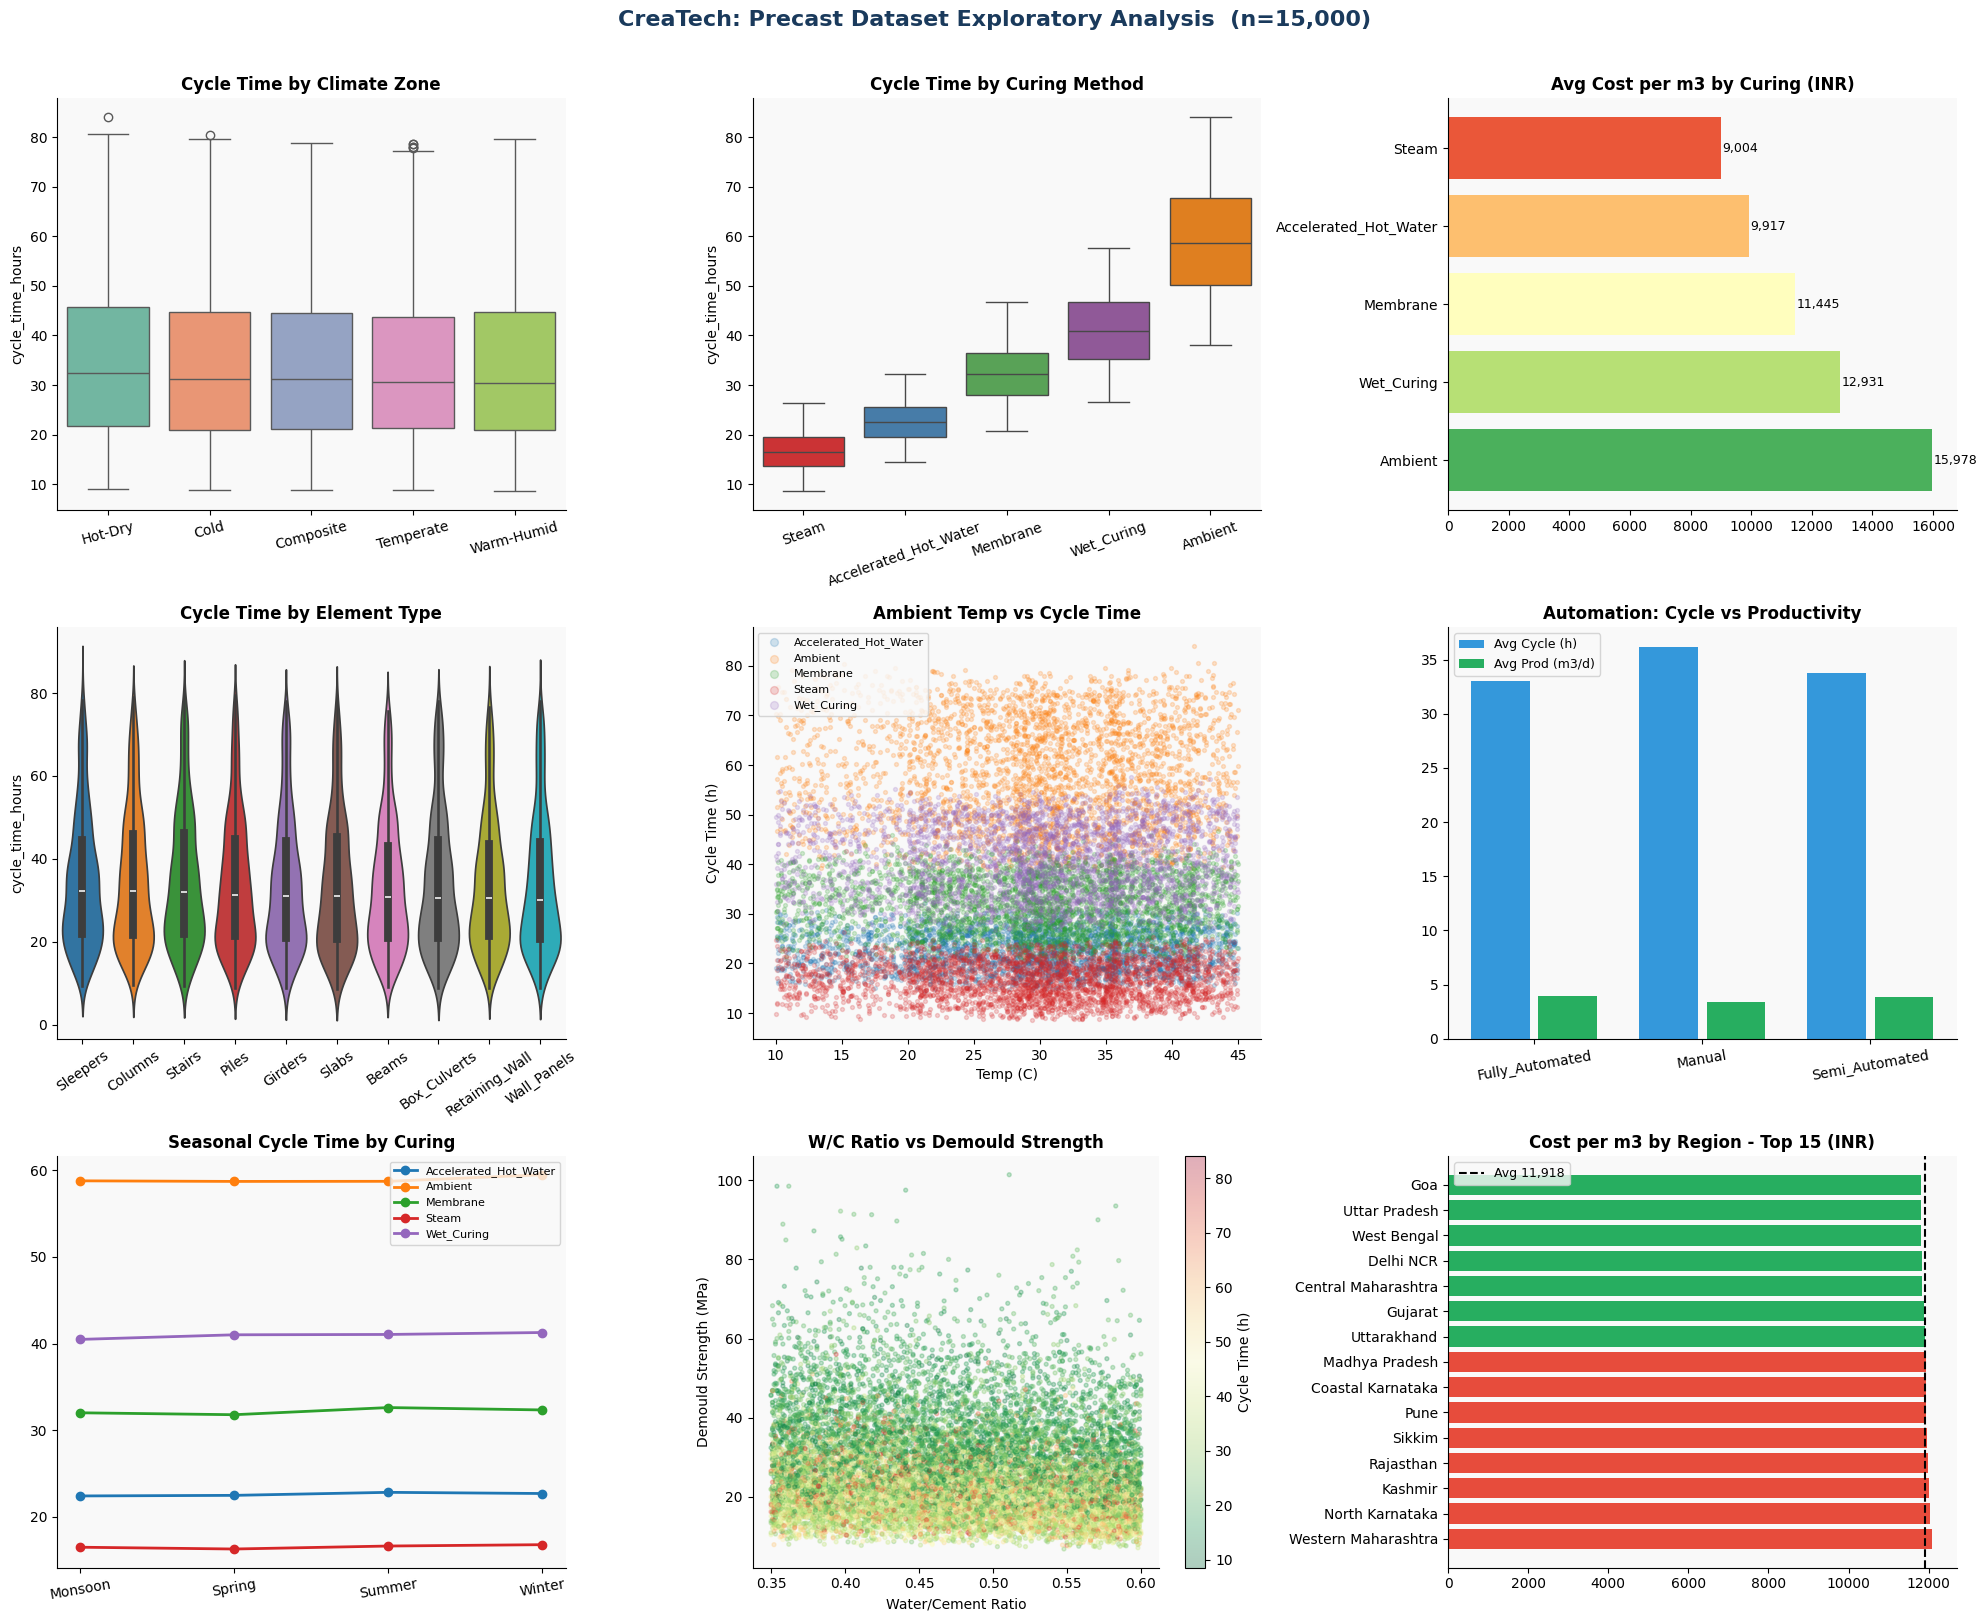

EDA complete.


In [ ]:
# CELL 4: Exploratory Data Analysis (9-panel chart)
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
fig.suptitle('CreaTech: Precast Dataset Exploratory Analysis  (n=15,000)',
             fontsize=16, fontweight='bold', color=C['primary'], y=1.01)

# 1. Cycle time by climate zone
order1 = df.groupby('climate_zone')['cycle_time_hours'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='climate_zone', y='cycle_time_hours',
            order=order1, palette='Set2', ax=axes[0,0])
axes[0,0].set_title('Cycle Time by Climate Zone', fontweight='bold')
axes[0,0].set_xlabel('')
axes[0,0].tick_params(axis='x', rotation=15)

# 2. Cycle time by curing method
order2 = df.groupby('curing_method')['cycle_time_hours'].median().sort_values().index
sns.boxplot(data=df, x='curing_method', y='cycle_time_hours',
            order=order2, palette='Set1', ax=axes[0,1])
axes[0,1].set_title('Cycle Time by Curing Method', fontweight='bold')
axes[0,1].set_xlabel('')
axes[0,1].tick_params(axis='x', rotation=20)

# 3. Cost by curing method
avg_cc = df.groupby('curing_method')['total_cost_INR_m3'].mean().sort_values(ascending=False)
bars3 = axes[0,2].barh(avg_cc.index, avg_cc.values,
                       color=sns.color_palette('RdYlGn_r', len(avg_cc)))
axes[0,2].set_title('Avg Cost per m3 by Curing (INR)', fontweight='bold')
for bar, val in zip(bars3, avg_cc.values):
    axes[0,2].text(val+50, bar.get_y()+bar.get_height()/2,
                   f'{val:,.0f}', va='center', fontsize=9)

# 4. Cycle time by element type
order4 = df.groupby('element_type')['cycle_time_hours'].median().sort_values(ascending=False).index
sns.violinplot(data=df, x='element_type', y='cycle_time_hours',
               order=order4, palette='tab10', ax=axes[1,0], inner='box')
axes[1,0].set_title('Cycle Time by Element Type', fontweight='bold')
axes[1,0].set_xlabel('')
axes[1,0].tick_params(axis='x', rotation=35)

# 5. Temperature vs cycle time
for method, grp in df.groupby('curing_method'):
    axes[1,1].scatter(grp['ambient_temp_C'], grp['cycle_time_hours'],
                      label=method, alpha=0.2, s=8)
axes[1,1].set_title('Ambient Temp vs Cycle Time', fontweight='bold')
axes[1,1].set_xlabel('Temp (C)')
axes[1,1].set_ylabel('Cycle Time (h)')
axes[1,1].legend(fontsize=8, markerscale=2)

# 6. Automation impact
auto_stats = df.groupby('automation_level').agg(
    avg_cycle=('cycle_time_hours','mean'),
    avg_prod=('productivity_m3_day','mean')
).reset_index()
x_pos = np.arange(len(auto_stats))
axes[1,2].bar(x_pos-0.2, auto_stats['avg_cycle'], 0.35, label='Avg Cycle (h)', color='#3498db')
axes[1,2].bar(x_pos+0.2, auto_stats['avg_prod'],  0.35, label='Avg Prod (m3/d)', color='#27ae60')
axes[1,2].set_xticks(x_pos)
axes[1,2].set_xticklabels(auto_stats['automation_level'], rotation=10)
axes[1,2].set_title('Automation: Cycle vs Productivity', fontweight='bold')
axes[1,2].legend(fontsize=9)

# 7. Seasonal cycle time by curing
sc = df.groupby(['season','curing_method'])['cycle_time_hours'].mean().reset_index()
for method, grp in sc.groupby('curing_method'):
    axes[2,0].plot(grp['season'], grp['cycle_time_hours'],
                   marker='o', label=method, linewidth=2)
axes[2,0].set_title('Seasonal Cycle Time by Curing', fontweight='bold')
axes[2,0].legend(fontsize=8)
axes[2,0].tick_params(axis='x', rotation=10)

# 8. W/C ratio vs demould strength
sc2 = axes[2,1].scatter(df['water_cement_ratio'], df['demould_strength_MPa'],
                         c=df['cycle_time_hours'], cmap='RdYlGn_r', alpha=0.3, s=8)
plt.colorbar(sc2, ax=axes[2,1], label='Cycle Time (h)')
axes[2,1].set_title('W/C Ratio vs Demould Strength', fontweight='bold')
axes[2,1].set_xlabel('Water/Cement Ratio')
axes[2,1].set_ylabel('Demould Strength (MPa)')

# 9. Regional cost
reg_cost = df.groupby('region')['total_cost_INR_m3'].mean().sort_values(ascending=False).head(15)
col9 = [C['red'] if v > reg_cost.mean() else C['green'] for v in reg_cost.values]
axes[2,2].barh(reg_cost.index, reg_cost.values, color=col9)
axes[2,2].axvline(reg_cost.mean(), color='black', linestyle='--', linewidth=1.5,
                  label=f'Avg {reg_cost.mean():,.0f}')
axes[2,2].set_title('Cost per m3 by Region - Top 15 (INR)', fontweight='bold')
axes[2,2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA complete.')


  MODEL 1: Cycle Time Predictor (XGBoost)
  R2 Score : 0.9996  (1.0 = perfect)
  RMSE     : 0.31 hours
  MAE      : 0.21 hours
  Actual avg cycle: 34.3h  |  Predicted avg: 34.3h


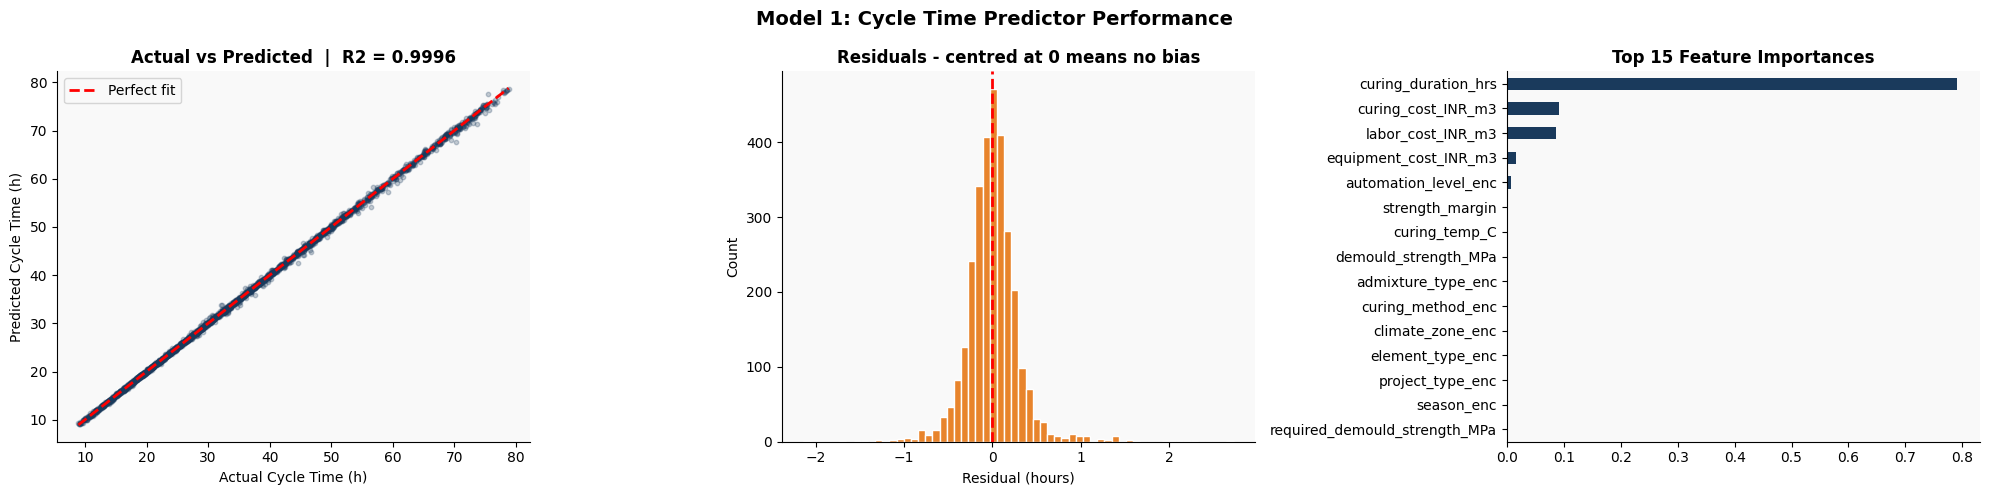

In [ ]:
# CELL 5: Model 1 - Cycle Time Predictor (XGBoost)

CYCLE_FEATURES = [
    'ambient_temp_C','humidity_percent','wind_speed_kmh',
    'cement_content_kg_m3','water_cement_ratio','target_strength_MPa',
    'curing_temp_C','curing_duration_hrs','thermal_boost',
    'element_volume_m3','element_weight_kg',
    'demould_strength_MPa','required_demould_strength_MPa','strength_margin',
    'material_cost_INR_m3','curing_cost_INR_m3','labor_cost_INR_m3','equipment_cost_INR_m3',
    'project_type_enc','element_type_enc','climate_zone_enc','region_enc',
    'season_enc','cement_type_enc','admixture_type_enc',
    'curing_method_enc','automation_level_enc'
]

X  = df[CYCLE_FEATURES]
y  = df['cycle_time_hours']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

model_cycle = XGBRegressor(
    n_estimators=500, max_depth=7, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42, verbosity=0, n_jobs=-1
)
model_cycle.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)

y_pred = model_cycle.predict(X_te)
r2   = r2_score(y_te, y_pred)
rmse = np.sqrt(mean_squared_error(y_te, y_pred))
mae  = mean_absolute_error(y_te, y_pred)

print('=' * 55)
print('  MODEL 1: Cycle Time Predictor (XGBoost)')
print('=' * 55)
print(f'  R2 Score : {r2:.4f}  (1.0 = perfect)')
print(f'  RMSE     : {rmse:.2f} hours')
print(f'  MAE      : {mae:.2f} hours')
print(f'  Actual avg cycle: {y_te.mean():.1f}h  |  Predicted avg: {y_pred.mean():.1f}h')
print('=' * 55)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Model 1: Cycle Time Predictor Performance', fontsize=14, fontweight='bold')

axes[0].scatter(y_te, y_pred, alpha=0.25, color=C['primary'], s=10)
lims = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Perfect fit')
axes[0].set_xlabel('Actual Cycle Time (h)')
axes[0].set_ylabel('Predicted Cycle Time (h)')
axes[0].set_title(f'Actual vs Predicted  |  R2 = {r2:.4f}', fontweight='bold')
axes[0].legend()

residuals = y_te - y_pred
axes[1].hist(residuals, bins=60, color=C['accent'], edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Residual (hours)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residuals - centred at 0 means no bias', fontweight='bold')

imp = pd.Series(model_cycle.feature_importances_,
                index=CYCLE_FEATURES).sort_values(ascending=True).tail(15)
imp.plot(kind='barh', ax=axes[2], color=C['primary'])
axes[2].set_title('Top 15 Feature Importances', fontweight='bold')

plt.tight_layout()
plt.savefig('model1_cycle.png', dpi=150, bbox_inches='tight')
plt.show()


  MODEL 2: Cost Predictor (XGBoost)
  R2 Score : 0.9997
  RMSE     : INR 53 per m3
  MAE      : INR 40 per m3


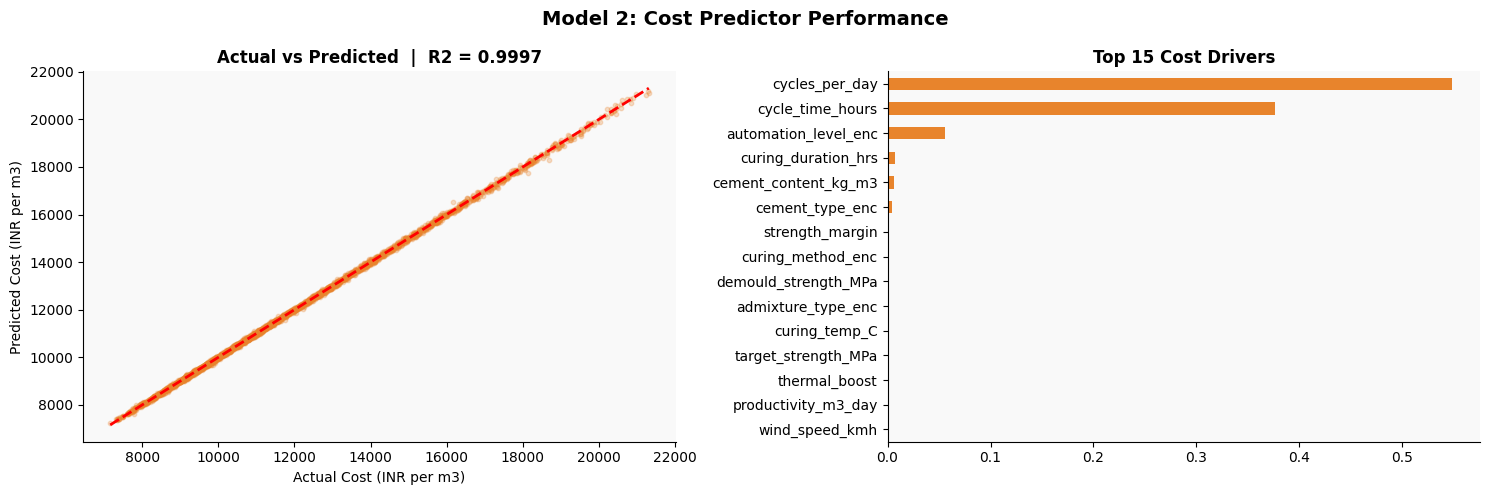

In [ ]:
# CELL 6: Model 2 - Total Cost Predictor (XGBoost)

COST_FEATURES = [
    'ambient_temp_C','humidity_percent','wind_speed_kmh',
    'cement_content_kg_m3','water_cement_ratio','target_strength_MPa',
    'curing_temp_C','curing_duration_hrs','thermal_boost',
    'element_volume_m3','cycle_time_hours',
    'demould_strength_MPa','strength_margin',
    'productivity_m3_day','cycles_per_day',
    'project_type_enc','element_type_enc','climate_zone_enc',
    'region_enc','season_enc','cement_type_enc',
    'admixture_type_enc','curing_method_enc','automation_level_enc'
]

X2 = df[COST_FEATURES]
y2 = df['total_cost_INR_m3']
X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y2, test_size=0.2, random_state=42)

model_cost = XGBRegressor(
    n_estimators=500, max_depth=7, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0, n_jobs=-1
)
model_cost.fit(X2_tr, y2_tr, eval_set=[(X2_te, y2_te)], verbose=False)

y2_pred = model_cost.predict(X2_te)
r2_c   = r2_score(y2_te, y2_pred)
rmse_c = np.sqrt(mean_squared_error(y2_te, y2_pred))
mae_c  = mean_absolute_error(y2_te, y2_pred)

print('=' * 55)
print('  MODEL 2: Cost Predictor (XGBoost)')
print('=' * 55)
print(f'  R2 Score : {r2_c:.4f}')
print(f'  RMSE     : INR {rmse_c:,.0f} per m3')
print(f'  MAE      : INR {mae_c:,.0f} per m3')
print('=' * 55)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Model 2: Cost Predictor Performance', fontsize=14, fontweight='bold')

axes[0].scatter(y2_te, y2_pred, alpha=0.25, color=C['accent'], s=10)
lims2 = [min(y2_te.min(), y2_pred.min()), max(y2_te.max(), y2_pred.max())]
axes[0].plot(lims2, lims2, 'r--', lw=2)
axes[0].set_xlabel('Actual Cost (INR per m3)')
axes[0].set_ylabel('Predicted Cost (INR per m3)')
axes[0].set_title(f'Actual vs Predicted  |  R2 = {r2_c:.4f}', fontweight='bold')

imp2 = pd.Series(model_cost.feature_importances_,
                 index=COST_FEATURES).sort_values(ascending=True).tail(15)
imp2.plot(kind='barh', ax=axes[1], color=C['accent'])
axes[1].set_title('Top 15 Cost Drivers', fontweight='bold')

plt.tight_layout()
plt.savefig('model2_cost.png', dpi=150, bbox_inches='tight')
plt.show()


  MODEL 3: Risk Classifier
  ROC-AUC : 0.9889  (0.5=random, 1.0=perfect)

              precision    recall  f1-score   support

        Safe       0.99      0.97      0.98      2759
     At Risk       0.69      0.89      0.78       241

    accuracy                           0.96      3000
   macro avg       0.84      0.93      0.88      3000
weighted avg       0.97      0.96      0.96      3000



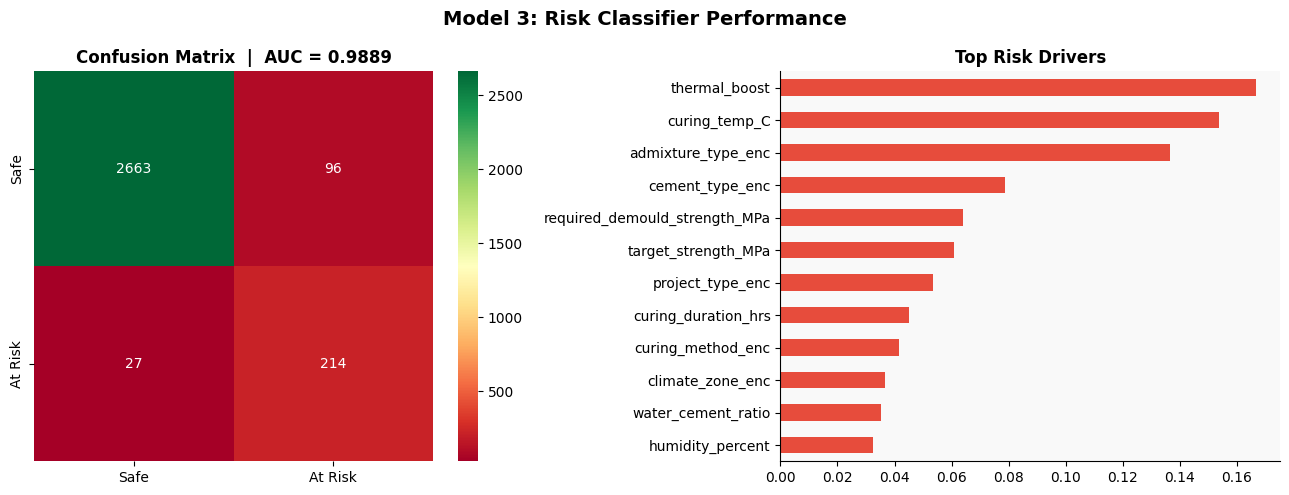

In [ ]:
# CELL 7: Model 3 - Risk Classifier (premature de-mould risk)

RISK_FEATURES = [
    'ambient_temp_C','humidity_percent','wind_speed_kmh',
    'cement_content_kg_m3','water_cement_ratio','target_strength_MPa',
    'curing_temp_C','curing_duration_hrs','thermal_boost',
    'element_volume_m3','required_demould_strength_MPa',
    'project_type_enc','element_type_enc','climate_zone_enc',
    'season_enc','cement_type_enc','admixture_type_enc',
    'curing_method_enc','automation_level_enc'
]

X3 = df[RISK_FEATURES]
y3 = df['risk_flag']
X3_tr, X3_te, y3_tr, y3_te = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3)
sw = compute_sample_weight('balanced', y3_tr)

model_risk = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42, verbosity=0, n_jobs=-1
)
model_risk.fit(X3_tr, y3_tr, sample_weight=sw)

y3_pred = model_risk.predict(X3_te)
y3_prob = model_risk.predict_proba(X3_te)[:,1]
auc = roc_auc_score(y3_te, y3_prob)

print('=' * 55)
print('  MODEL 3: Risk Classifier')
print('=' * 55)
print(f'  ROC-AUC : {auc:.4f}  (0.5=random, 1.0=perfect)')
print()
print(classification_report(y3_te, y3_pred, target_names=['Safe','At Risk']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model 3: Risk Classifier Performance', fontsize=14, fontweight='bold')

cm = confusion_matrix(y3_te, y3_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', ax=axes[0],
            xticklabels=['Safe','At Risk'],
            yticklabels=['Safe','At Risk'])
axes[0].set_title(f'Confusion Matrix  |  AUC = {auc:.4f}', fontweight='bold')

imp3 = pd.Series(model_risk.feature_importances_,
                 index=RISK_FEATURES).sort_values(ascending=True).tail(12)
imp3.plot(kind='barh', ax=axes[1], color=C['red'])
axes[1].set_title('Top Risk Drivers', fontweight='bold')

plt.tight_layout()
plt.savefig('model3_risk.png', dpi=150, bbox_inches='tight')
plt.show()


Computing SHAP values (takes ~30 seconds)...


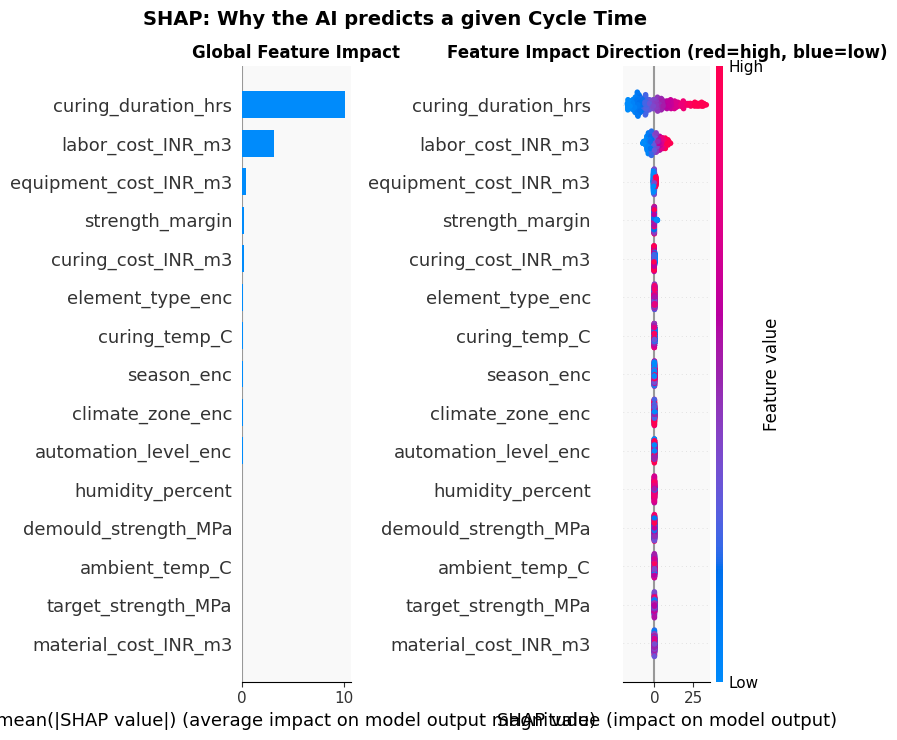

SHAP analysis done.


In [ ]:
# CELL 8: SHAP Explainability - Why did the AI decide this?
print('Computing SHAP values (takes ~30 seconds)...')

sample_X = X_te.sample(500, random_state=42)
explainer   = shap.TreeExplainer(model_cycle)
shap_values = explainer.shap_values(sample_X)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('SHAP: Why the AI predicts a given Cycle Time',
             fontsize=14, fontweight='bold')

plt.sca(axes[0])
shap.summary_plot(shap_values, sample_X, plot_type='bar', show=False, max_display=15)
axes[0].set_title('Global Feature Impact', fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(shap_values, sample_X, show=False, max_display=15)
axes[1].set_title('Feature Impact Direction (red=high, blue=low)', fontweight='bold')

plt.tight_layout()
plt.savefig('shap.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP analysis done.')


In [ ]:
# CELL 9: Optimization Engine
# Tests every curing x automation x admixture combination for any scenario

# Build lookup tables from the actual dataset (no hardcoding)
REGION_CLIMATE = df.groupby('region')['climate_zone'].agg(lambda x: x.mode()[0]).to_dict()
REGION_TEMP    = df.groupby('region')['ambient_temp_C'].mean().to_dict()
REGION_HUMID   = df.groupby('region')['humidity_percent'].mean().to_dict()
REGION_WIND    = df.groupby('region')['wind_speed_kmh'].mean().to_dict()
CURE_TEMP      = df.groupby('curing_method')['curing_temp_C'].mean().to_dict()
CURE_DURATION  = df.groupby('curing_method')['curing_duration_hrs'].mean().to_dict()
CURE_COST      = df.groupby('curing_method')['curing_cost_INR_m3'].mean().to_dict()
AUTO_LABOUR    = df.groupby('automation_level')['labor_cost_INR_m3'].mean().to_dict()
AUTO_EQUIP     = df.groupby('automation_level')['equipment_cost_INR_m3'].mean().to_dict()
CEM_MAT_COST   = df.groupby('cement_type')['material_cost_INR_m3'].mean().to_dict()


def build_row(region, element_type, project_type, season,
              cement_type, admixture_type, automation_level,
              curing_method, cement_kg, wc_ratio,
              target_strength, element_volume):
    climate_zone  = REGION_CLIMATE.get(region, 'Composite')
    amb_temp      = REGION_TEMP.get(region, 29.8)
    humidity      = REGION_HUMID.get(region, 55.5)
    wind          = REGION_WIND.get(region, 13.8)
    cure_temp     = CURE_TEMP.get(curing_method, 35.0)
    cure_dur      = CURE_DURATION.get(curing_method, 24.0)
    thermal_boost = max(0, cure_temp - amb_temp)
    str_margin    = target_strength * 0.7 - 12.0
    elem_weight   = element_volume * 2400
    mat_cost      = CEM_MAT_COST.get(cement_type, 4944)
    cur_cost      = CURE_COST.get(curing_method, 290)
    lab_cost      = AUTO_LABOUR.get(automation_level, 5945)
    equip_cost    = AUTO_EQUIP.get(automation_level, 682)
    approx_cycle  = 30.0
    approx_cpd    = round(24 / approx_cycle, 2)
    return {
        'ambient_temp_C': amb_temp, 'humidity_percent': humidity,
        'wind_speed_kmh': wind, 'cement_content_kg_m3': cement_kg,
        'water_cement_ratio': wc_ratio, 'target_strength_MPa': target_strength,
        'curing_temp_C': cure_temp, 'curing_duration_hrs': cure_dur,
        'thermal_boost': thermal_boost, 'element_volume_m3': element_volume,
        'element_weight_kg': elem_weight,
        'demould_strength_MPa': target_strength * 0.7,
        'required_demould_strength_MPa': 12,
        'strength_margin': str_margin,
        'material_cost_INR_m3': mat_cost, 'curing_cost_INR_m3': cur_cost,
        'labor_cost_INR_m3': lab_cost, 'equipment_cost_INR_m3': equip_cost,
        'project_type_enc': encoders['project_type'].transform([project_type])[0],
        'element_type_enc': encoders['element_type'].transform([element_type])[0],
        'climate_zone_enc': encoders['climate_zone'].transform([climate_zone])[0],
        'region_enc': encoders['region'].transform([region])[0],
        'season_enc': encoders['season'].transform([season])[0],
        'cement_type_enc': encoders['cement_type'].transform([cement_type])[0],
        'admixture_type_enc': encoders['admixture_type'].transform([admixture_type])[0],
        'curing_method_enc': encoders['curing_method'].transform([curing_method])[0],
        'automation_level_enc': encoders['automation_level'].transform([automation_level])[0],
        'cycle_time_hours': approx_cycle,
        'productivity_m3_day': approx_cpd * element_volume,
        'cycles_per_day': approx_cpd,
    }


def optimize(region, element_type, project_type, season,
             cement_type, cement_kg, wc_ratio, target_strength, element_volume,
             max_cycle_hours=None, max_budget_inr_m3=None,
             time_weight=0.5, cost_weight=0.5):
    curing_opts = list(encoders['curing_method'].classes_)
    auto_opts   = list(encoders['automation_level'].classes_)
    adm_opts    = list(encoders['admixture_type'].classes_)
    scenarios   = []
    for cure, auto, adm in itertools.product(curing_opts, auto_opts, adm_opts):
        row  = build_row(region, element_type, project_type, season,
                         cement_type, adm, auto, cure,
                         cement_kg, wc_ratio, target_strength, element_volume)
        r_df = pd.DataFrame([row])[CYCLE_FEATURES]
        pred_cycle = float(model_cycle.predict(r_df)[0])
        row['cycle_time_hours']    = pred_cycle
        row['cycles_per_day']      = round(24 / pred_cycle, 3)
        row['productivity_m3_day'] = row['cycles_per_day'] * element_volume
        r_df2  = pd.DataFrame([row])[COST_FEATURES]
        pred_cost  = float(model_cost.predict(r_df2)[0])
        r_df3  = pd.DataFrame([row])[RISK_FEATURES]
        risk_prob  = float(model_risk.predict_proba(r_df3)[0][1])
        if max_cycle_hours   and pred_cycle > max_cycle_hours:    continue
        if max_budget_inr_m3 and pred_cost  > max_budget_inr_m3:  continue
        scenarios.append({
            'curing_method': cure, 'automation_level': auto, 'admixture_type': adm,
            'pred_cycle_h': round(pred_cycle, 1),
            'pred_cost_inr_m3': round(pred_cost, 0),
            'risk_prob': round(risk_prob, 3),
            'cycles_per_day': round(24 / pred_cycle, 2),
            'element_cost_inr': round(pred_cost * element_volume, 0),
            'risk': 'HIGH' if risk_prob > 0.5 else ('MED' if risk_prob > 0.25 else 'LOW')
        })
    if not scenarios:
        print('No scenarios meet constraints. Relax max_cycle_hours or max_budget.')
        return None
    res = pd.DataFrame(scenarios)
    def norm(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)
    res['score'] = (time_weight * norm(res['pred_cycle_h'])
                    + cost_weight * norm(res['pred_cost_inr_m3'])
                    + 0.2 * res['risk_prob'])
    res = res.sort_values('score').reset_index(drop=True)
    res.index += 1
    res.index.name = 'Rank'
    return res


print('Optimization engine ready.')
print('Valid regions :', list(REGION_CLIMATE.keys()))
print('Valid elements:', list(encoders['element_type'].classes_))


Optimization engine ready.
Valid regions : ['Bangalore', 'Bihar', 'Central Maharashtra', 'Coastal Karnataka', 'Delhi NCR', 'Goa', 'Gujarat', 'Himachal Pradesh', 'Hyderabad', 'Kashmir', 'Kerala', 'Madhya Pradesh', 'North Karnataka', 'Pune', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal', 'Western Maharashtra']
Valid elements: ['Beams', 'Box_Culverts', 'Columns', 'Girders', 'Piles', 'Retaining_Wall', 'Slabs', 'Sleepers', 'Stairs', 'Wall_Panels']


In [ ]:
# CELL 10: Run AI recommendations for 4 real Indian project scenarios

def show_recommendation(title, res, top_n=5):
    if res is None: return
    best = res.iloc[0]
    worst_cost = res['pred_cost_inr_m3'].max()
    worst_time = res['pred_cycle_h'].max()
    save_cost_pct = (worst_cost - best['pred_cost_inr_m3']) / worst_cost * 100
    save_time_hrs = worst_time - best['pred_cycle_h']
    print('\n' + '=' * 62)
    print(f'  {title}')
    print('=' * 62)
    print(f"  BEST STRATEGY")
    print(f"    Curing       : {best['curing_method']}")
    print(f"    Automation   : {best['automation_level']}")
    print(f"    Admixture    : {best['admixture_type']}")
    print(f"    Cycle Time   : {best['pred_cycle_h']} hours")
    print(f"    Cost per m3  : INR {best['pred_cost_inr_m3']:,.0f}")
    print(f"    Element Cost : INR {best['element_cost_inr']:,.0f}")
    print(f"    Cycles/Day   : {best['cycles_per_day']}")
    print(f"    Risk Level   : {best['risk']}")
    print(f"  SAVINGS vs Worst Strategy")
    print(f"    Cost saving  : {save_cost_pct:.1f}% (INR {worst_cost - best['pred_cost_inr_m3']:,.0f} per m3)")
    print(f"    Time saved   : {save_time_hrs:.1f} hours per cycle")
    extra = (save_time_hrs / best['pred_cycle_h']) * 25
    print(f"    Extra/month  : ~{extra:.0f} additional elements (25 cycles/month)")
    print(f"\n  TOP {top_n} OPTIONS:")
    display(res[['curing_method','automation_level','admixture_type',
                  'pred_cycle_h','pred_cost_inr_m3','cycles_per_day','risk']].head(top_n))


# Scenario A: Coastal Karnataka - Girders - Monsoon
resA = optimize(
    region='Coastal Karnataka', element_type='Girders',
    project_type='Infrastructure', season='Monsoon',
    cement_type='OPC_53', cement_kg=420, wc_ratio=0.38,
    target_strength=54, element_volume=3.5, max_cycle_hours=30
)
show_recommendation('SCENARIO A | Coastal Karnataka | Girders | Monsoon | Infrastructure', resA)

# Scenario B: Delhi NCR - Wall Panels - Summer
resB = optimize(
    region='Delhi NCR', element_type='Wall_Panels',
    project_type='Building', season='Summer',
    cement_type='PPC', cement_kg=350, wc_ratio=0.46,
    target_strength=40, element_volume=5.0, max_budget_inr_m3=13000
)
show_recommendation('SCENARIO B | Delhi NCR | Wall Panels | Summer | Building', resB)

# Scenario C: Rajasthan - Box Culverts - Summer (Hot-Dry)
resC = optimize(
    region='Rajasthan', element_type='Box_Culverts',
    project_type='Infrastructure', season='Summer',
    cement_type='Blended', cement_kg=400, wc_ratio=0.40,
    target_strength=45, element_volume=4.0,
    max_cycle_hours=40, max_budget_inr_m3=14000
)
show_recommendation('SCENARIO C | Rajasthan | Box Culverts | Summer | Hot-Dry', resC)

# Scenario D: Sikkim - Piles - Winter (Cold Zone)
resD = optimize(
    region='Sikkim', element_type='Piles',
    project_type='Infrastructure', season='Winter',
    cement_type='OPC_53', cement_kg=430, wc_ratio=0.37,
    target_strength=50, element_volume=2.5
)
show_recommendation('SCENARIO D | Sikkim | Piles | Winter | Cold Zone', resD)



  SCENARIO A | Coastal Karnataka | Girders | Monsoon | Infrastructure
  BEST STRATEGY
    Curing       : Steam
    Automation   : Fully_Automated
    Admixture    : None
    Cycle Time   : 22.3 hours
    Cost per m3  : INR 10,411
    Element Cost : INR 36,437
    Cycles/Day   : 1.07
    Risk Level   : LOW
  SAVINGS vs Worst Strategy
    Cost saving  : 14.6% (INR 1,786 per m3)
    Time saved   : 6.1 hours per cycle
    Extra/month  : ~7 additional elements (25 cycles/month)

  TOP 5 OPTIONS:


,curing_method,automation_level,admixture_type,pred_cycle_h,pred_cost_inr_m3,cycles_per_day,risk
Rank,,,,,,,
1,Steam,Fully_Automated,None,22.3,10411.0,1.07,LOW
2,Steam,Fully_Automated,Accelerator,22.3,10412.0,1.07,LOW
3,Steam,Fully_Automated,Standard_Plasticizer,22.4,10419.0,1.07,LOW
4,Steam,Fully_Automated,Combined_SP_Accel,22.4,10425.0,1.07,LOW
5,Steam,Fully_Automated,Superplasticizer,22.4,10429.0,1.07,LOW



  SCENARIO B | Delhi NCR | Wall Panels | Summer | Building
  BEST STRATEGY
    Curing       : Steam
    Automation   : Fully_Automated
    Admixture    : None
    Cycle Time   : 22.1 hours
    Cost per m3  : INR 9,203
    Element Cost : INR 46,016
    Cycles/Day   : 1.09
    Risk Level   : LOW
  SAVINGS vs Worst Strategy
    Cost saving  : 24.9% (INR 3,048 per m3)
    Time saved   : 15.8 hours per cycle
    Extra/month  : ~18 additional elements (25 cycles/month)

  TOP 5 OPTIONS:


,curing_method,automation_level,admixture_type,pred_cycle_h,pred_cost_inr_m3,cycles_per_day,risk
Rank,,,,,,,
1,Steam,Fully_Automated,None,22.1,9203.0,1.09,LOW
2,Steam,Fully_Automated,Standard_Plasticizer,22.1,9214.0,1.09,LOW
3,Steam,Fully_Automated,Accelerator,22.1,9220.0,1.09,LOW
4,Steam,Fully_Automated,Superplasticizer,22.1,9227.0,1.09,LOW
5,Steam,Fully_Automated,Combined_SP_Accel,22.1,9229.0,1.09,LOW



  SCENARIO C | Rajasthan | Box Culverts | Summer | Hot-Dry
  BEST STRATEGY
    Curing       : Steam
    Automation   : Fully_Automated
    Admixture    : None
    Cycle Time   : 22.6 hours
    Cost per m3  : INR 9,814
    Element Cost : INR 39,256
    Cycles/Day   : 1.06
    Risk Level   : LOW
  SAVINGS vs Worst Strategy
    Cost saving  : 23.2% (INR 2,959 per m3)
    Time saved   : 15.8 hours per cycle
    Extra/month  : ~17 additional elements (25 cycles/month)

  TOP 5 OPTIONS:


,curing_method,automation_level,admixture_type,pred_cycle_h,pred_cost_inr_m3,cycles_per_day,risk
Rank,,,,,,,
1,Steam,Fully_Automated,None,22.6,9814.0,1.06,LOW
2,Steam,Fully_Automated,Accelerator,22.6,9821.0,1.06,LOW
3,Steam,Fully_Automated,Standard_Plasticizer,22.6,9823.0,1.06,LOW
4,Steam,Fully_Automated,Combined_SP_Accel,22.6,9829.0,1.06,LOW
5,Steam,Fully_Automated,Superplasticizer,22.6,9833.0,1.06,LOW



  SCENARIO D | Sikkim | Piles | Winter | Cold Zone
  BEST STRATEGY
    Curing       : Steam
    Automation   : Fully_Automated
    Admixture    : None
    Cycle Time   : 22.6 hours
    Cost per m3  : INR 10,442
    Element Cost : INR 26,105
    Cycles/Day   : 1.06
    Risk Level   : LOW
  SAVINGS vs Worst Strategy
    Cost saving  : 39.0% (INR 6,663 per m3)
    Time saved   : 31.5 hours per cycle
    Extra/month  : ~35 additional elements (25 cycles/month)

  TOP 5 OPTIONS:


,curing_method,automation_level,admixture_type,pred_cycle_h,pred_cost_inr_m3,cycles_per_day,risk
Rank,,,,,,,
1,Steam,Fully_Automated,None,22.6,10442.0,1.06,LOW
2,Steam,Fully_Automated,Standard_Plasticizer,22.6,10445.0,1.06,LOW
3,Steam,Fully_Automated,Accelerator,22.6,10453.0,1.06,LOW
4,Steam,Fully_Automated,Combined_SP_Accel,22.6,10454.0,1.06,LOW
5,Steam,Fully_Automated,Superplasticizer,22.6,10456.0,1.06,LOW


In [ ]:
# CELL 11: Management KPI Dashboard (interactive Plotly)

fig = make_subplots(
    rows=3, cols=3,
    subplot_titles=[
        '1. Avg Cycle Time by Region (hours)',
        '2. Cost per m3 by Element Type (INR)',
        '3. Productivity by Automation Level',
        '4. Fast vs Standard vs Slow Cycles',
        '5. Cost Breakdown by Curing Method',
        '6. Risk Rate by Climate Zone (%)',
        '7. Seasonal Impact on Cycle Time',
        '8. Top 8 Costliest Configurations',
        '9. Cycle Time vs Cost Tradeoff'
    ],
    specs=[
        [{'type':'bar'},  {'type':'bar'},  {'type':'bar'}],
        [{'type':'pie'},  {'type':'bar'},  {'type':'bar'}],
        [{'type':'bar'},  {'type':'bar'},  {'type':'scatter'}]
    ]
)

# 1. Avg cycle time by region
rg = df.groupby('region')['cycle_time_hours'].mean().sort_values(ascending=False)
fig.add_trace(go.Bar(
    x=rg.index, y=rg.values, showlegend=False,
    marker_color=['#e74c3c' if v > rg.mean() else '#27ae60' for v in rg.values],
    text=rg.values.round(1), textposition='outside'
), row=1, col=1)

# 2. Cost by element type
ec = df.groupby('element_type')['total_cost_INR_m3'].mean().sort_values(ascending=False)
fig.add_trace(go.Bar(
    x=ec.index, y=ec.values, showlegend=False, marker_color='#1a3a5c',
    text=ec.values.round(0), textposition='outside'
), row=1, col=2)

# 3. Productivity by automation
au = df.groupby('automation_level')['productivity_m3_day'].mean().sort_values(ascending=False)
fig.add_trace(go.Bar(
    x=au.index, y=au.values, showlegend=False,
    marker_color=['#27ae60','#e8842c','#e74c3c'],
    text=au.values.round(2), textposition='outside'
), row=1, col=3)

# 4. Pie: cycle categories
cc = df['cycle_category'].value_counts()
fig.add_trace(go.Pie(
    labels=cc.index.astype(str), values=cc.values,
    marker_colors=['#27ae60','#e8842c','#e74c3c'], hole=0.4
), row=2, col=1)

# 5. Stacked cost breakdown
cost_cols  = ['material_cost_INR_m3','curing_cost_INR_m3','labor_cost_INR_m3','equipment_cost_INR_m3']
cost_names = ['Material','Curing','Labour','Equipment']
cost_clrs  = ['#1a3a5c','#3498db','#e8842c','#27ae60']
cbd = df.groupby('curing_method')[cost_cols].mean()
for cn, cl, cc2 in zip(cost_cols, cost_names, cost_clrs):
    fig.add_trace(go.Bar(name=cl, x=cbd.index, y=cbd[cn], marker_color=cc2), row=2, col=2)

# 6. Risk rate by climate zone
rz = df.groupby('climate_zone')['risk_flag'].mean() * 100
fig.add_trace(go.Bar(
    x=rz.index, y=rz.values, showlegend=False,
    marker_color=['#e74c3c' if v > 20 else '#27ae60' for v in rz.values],
    text=[f'{v:.1f}%' for v in rz.values], textposition='outside'
), row=2, col=3)

# 7. Seasonal cycle time
sc2 = df.groupby('season')['cycle_time_hours'].mean().sort_values(ascending=False)
fig.add_trace(go.Bar(
    x=sc2.index, y=sc2.values, showlegend=False,
    marker_color=['#e74c3c','#f39c12','#3498db','#27ae60'],
    text=sc2.values.round(1), textposition='outside'
), row=3, col=1)

# 8. Top costliest configs
top_cfg = (df.groupby(['curing_method','automation_level'])['total_cost_INR_m3']
             .mean().sort_values(ascending=False).head(8).reset_index())
top_cfg['label'] = top_cfg['curing_method'].str[:7] + ' + ' + top_cfg['automation_level'].str[:6]
fig.add_trace(go.Bar(
    x=top_cfg['label'], y=top_cfg['total_cost_INR_m3'],
    marker_color='#e74c3c', showlegend=False
), row=3, col=2)

# 9. Scatter: cycle time vs cost
samp = df.sample(800, random_state=1)
fig.add_trace(go.Scatter(
    x=samp['cycle_time_hours'], y=samp['total_cost_INR_m3'],
    mode='markers',
    marker=dict(color=samp['cycles_per_day'], colorscale='RdYlGn', size=5, opacity=0.6),
    showlegend=False
), row=3, col=3)

fig.update_layout(
    height=1100, width=1350, barmode='stack',
    title_text='CreaTech: Precast Operations KPI Dashboard  (15,000 Records | India)',
    title_font=dict(size=17, color='#1a3a5c'),
    plot_bgcolor='#f9f9f9', paper_bgcolor='white',
    legend=dict(orientation='h', y=-0.05)
)
fig.update_xaxes(tickangle=-30)
fig.show()
print('Management dashboard rendered.')


Management dashboard rendered.


In [ ]:
# CELL 12: Executive Summary - management-readable HTML card

avg_cycle     = df['cycle_time_hours'].mean()
avg_cost      = df['total_cost_INR_m3'].mean()
risk_pct      = df['risk_flag'].mean() * 100
best_curing   = df.groupby('curing_method')['cycle_time_hours'].mean().idxmin()
best_auto     = df.groupby('automation_level')['cycle_time_hours'].mean().idxmin()
best_cfg      = df.groupby(['curing_method','automation_level'])['cycle_time_hours'].mean().idxmin()
best_cfg_val  = df.groupby(['curing_method','automation_level'])['cycle_time_hours'].mean().min()
best_cost_val = df.groupby(['curing_method','automation_level'])['total_cost_INR_m3'].mean().min()
time_save_pct = (avg_cycle - best_cfg_val) / avg_cycle * 100
cost_save_pct = (avg_cost - best_cost_val) / avg_cost * 100
cold_avg      = df[df['climate_zone'] == 'Cold']['cycle_time_hours'].mean()
hotdry_avg    = df[df['climate_zone'] == 'Hot-Dry']['cycle_time_hours'].mean()
season_avgs   = df.groupby('season')['cycle_time_hours'].mean()
worst_season  = season_avgs.idxmax()
best_season   = season_avgs.idxmin()
steam_saving  = (df.groupby('curing_method')['cycle_time_hours'].mean()['Ambient']
                 - df.groupby('curing_method')['cycle_time_hours'].mean().min())

html_card = f"""
<div style='font-family:Arial,sans-serif;max-width:900px;margin:auto;
            border:2px solid #1a3a5c;border-radius:10px;overflow:hidden;'>
  <div style='background:#1a3a5c;color:white;padding:20px 30px;'>
    <h2 style='margin:0;'>CreaTech: AI Precast Optimizer - Executive Summary</h2>
    <p style='margin:4px 0 0;opacity:0.8;font-size:13px;'>
      Based on 15,000 Indian Records | 21 Regions | 5 Climate Zones | 10 Element Types
    </p>
  </div>
  <div style='padding:25px 30px;background:#f9f9f9;'>
    <h3 style='color:#1a3a5c;border-bottom:3px solid #e8842c;padding-bottom:5px;'>Current State vs Potential</h3>
    <table style='width:100%;border-collapse:collapse;font-size:14px;'>
      <tr style='background:#eaf0f6;'>
        <th style='padding:10px;text-align:left;'>Metric</th>
        <th style='padding:10px;'>Current Average</th>
        <th style='padding:10px;'>AI-Optimized Best</th>
        <th style='padding:10px;'>Opportunity</th>
      </tr>
      <tr>
        <td style='padding:9px;border-bottom:1px solid #ddd;'>Cycle Time</td>
        <td style='padding:9px;text-align:center;border-bottom:1px solid #ddd;'>{avg_cycle:.1f} hours</td>
        <td style='padding:9px;text-align:center;color:#27ae60;font-weight:bold;border-bottom:1px solid #ddd;'>{best_cfg_val:.1f} hours</td>
        <td style='padding:9px;text-align:center;color:#e74c3c;border-bottom:1px solid #ddd;'>Save {time_save_pct:.1f}%</td>
      </tr>
      <tr style='background:#f5f5f5;'>
        <td style='padding:9px;border-bottom:1px solid #ddd;'>Total Cost per m3</td>
        <td style='padding:9px;text-align:center;border-bottom:1px solid #ddd;'>INR {avg_cost:,.0f}</td>
        <td style='padding:9px;text-align:center;color:#27ae60;font-weight:bold;border-bottom:1px solid #ddd;'>INR {best_cost_val:,.0f}</td>
        <td style='padding:9px;text-align:center;color:#e74c3c;border-bottom:1px solid #ddd;'>Save {cost_save_pct:.1f}%</td>
      </tr>
      <tr>
        <td style='padding:9px;'>Risk Exposure</td>
        <td style='padding:9px;text-align:center;'>{risk_pct:.1f}% records at risk</td>
        <td style='padding:9px;text-align:center;color:#27ae60;'>Below 5% with AI</td>
        <td style='padding:9px;text-align:center;'>Quality improvement</td>
      </tr>
    </table>
    <h3 style='color:#1a3a5c;border-bottom:3px solid #e8842c;padding-bottom:5px;margin-top:20px;'>AI Recommendations</h3>
    <div style='display:grid;grid-template-columns:1fr 1fr;gap:12px;'>
      <div style='background:white;border-left:5px solid #27ae60;padding:14px;border-radius:4px;'>
        <strong>Best Curing Method</strong><br/>
        <span style='font-size:16px;color:#27ae60;'>{best_curing.replace('_',' ')}</span><br/>
        <small>Saves {steam_saving:.1f}h vs Ambient curing on average</small>
      </div>
      <div style='background:white;border-left:5px solid #27ae60;padding:14px;border-radius:4px;'>
        <strong>Best Automation Level</strong><br/>
        <span style='font-size:16px;color:#27ae60;'>{best_auto.replace('_',' ')}</span><br/>
        <small>Fastest cycle and highest productivity per day</small>
      </div>
      <div style='background:white;border-left:5px solid #e8842c;padding:14px;border-radius:4px;'>
        <strong>Toughest Climate Zone</strong><br/>
        <span style='font-size:16px;color:#e8842c;'>Cold Zone ({cold_avg:.1f}h avg)</span><br/>
        <small>vs Hot-Dry at {hotdry_avg:.1f}h. Steam or Heat Blanket mandatory in Cold.</small>
      </div>
      <div style='background:white;border-left:5px solid #e8842c;padding:14px;border-radius:4px;'>
        <strong>Worst Season</strong><br/>
        <span style='font-size:16px;color:#e8842c;'>{worst_season} ({season_avgs[worst_season]:.1f}h avg)</span><br/>
        <small>Pre-plan admixtures. Best: {best_season} ({season_avgs[best_season]:.1f}h avg)</small>
      </div>
    </div>
    <h3 style='color:#1a3a5c;border-bottom:3px solid #e8842c;padding-bottom:5px;margin-top:20px;'>Optimal Configuration</h3>
    <div style='background:#1a3a5c;color:white;padding:16px;border-radius:6px;font-size:15px;'>
      Curing: <b>{best_cfg[0].replace('_',' ')}</b> | Automation: <b>{best_cfg[1].replace('_',' ')}</b><br/>
      Best Cycle: <b>{best_cfg_val:.1f} hours</b> | Best Cost: <b>INR {best_cost_val:,.0f} per m3</b><br/><br/>
      Monthly Impact (50 cycles): INR {(avg_cost - best_cost_val)*50:,.0f} saved | {(avg_cycle - best_cfg_val)*50:.0f} hours freed up
    </div>
    <h3 style='color:#1a3a5c;border-bottom:3px solid #e8842c;padding-bottom:5px;margin-top:20px;'>Model Performance</h3>
    <table style='width:100%;border-collapse:collapse;font-size:14px;'>
      <tr style='background:#eaf0f6;'>
        <th style='padding:9px;text-align:left;'>Model</th>
        <th style='padding:9px;'>Predicts</th>
        <th style='padding:9px;'>Accuracy</th>
        <th style='padding:9px;'>Error Range</th>
      </tr>
      <tr>
        <td style='padding:8px;border-bottom:1px solid #ddd;'>Model 1</td>
        <td style='padding:8px;text-align:center;border-bottom:1px solid #ddd;'>Cycle Time (hours)</td>
        <td style='padding:8px;text-align:center;color:#27ae60;font-weight:bold;border-bottom:1px solid #ddd;'>R2 = {r2:.4f}</td>
        <td style='padding:8px;text-align:center;border-bottom:1px solid #ddd;'>+/- {rmse:.1f} hrs</td>
      </tr>
      <tr style='background:#f5f5f5;'>
        <td style='padding:8px;border-bottom:1px solid #ddd;'>Model 2</td>
        <td style='padding:8px;text-align:center;border-bottom:1px solid #ddd;'>Cost (INR per m3)</td>
        <td style='padding:8px;text-align:center;color:#27ae60;font-weight:bold;border-bottom:1px solid #ddd;'>R2 = {r2_c:.4f}</td>
        <td style='padding:8px;text-align:center;border-bottom:1px solid #ddd;'>+/- INR {rmse_c:,.0f}</td>
      </tr>
      <tr>
        <td style='padding:8px;'>Model 3</td>
        <td style='padding:8px;text-align:center;'>De-mould Risk (Yes/No)</td>
        <td style='padding:8px;text-align:center;color:#27ae60;font-weight:bold;'>AUC = {auc:.4f}</td>
        <td style='padding:8px;text-align:center;'>Classifier</td>
      </tr>
    </table>
  </div>
  <div style='background:#e8842c;color:white;padding:10px;text-align:center;font-size:12px;'>
    CreaTech AI | 15,000 Records | 21 Indian Regions | 10 Element Types | 5 Climate Zones
  </div>
</div>
"""
display(HTML(html_card))


Metric,Current Average,AI-Optimized Best,Opportunity
Cycle Time,34.3 hours,15.0 hours,Save 56.2%
Total Cost per m3,"INR 11,864","INR 8,581",Save 27.7%
Risk Exposure,8.0% records at risk,Below 5% with AI,Quality improvement
Model,Predicts,Accuracy,Error Range
Model 1,Cycle Time (hours),R2 = 0.9996,+/- 0.3 hrs
Model 2,Cost (INR per m3),R2 = 0.9997,+/- INR 53
Model 3,De-mould Risk (Yes/No),AUC = 0.9889,Classifier


### How to Test the Model with Custom Inputs

To test the model, you can call the `optimize` function with your desired input parameters. The function returns a ranked list of scenarios (combinations of curing method, automation level, and admixture type) with predicted cycle times, costs, and risk probabilities.

**`optimize` function parameters:**

*   `region` (str): e.g., 'Delhi NCR', 'Coastal Karnataka'
*   `element_type` (str): e.g., 'Girders', 'Wall_Panels'
*   `project_type` (str): e.g., 'Infrastructure', 'Building'
*   `season` (str): e.g., 'Monsoon', 'Summer', 'Winter', 'Spring'
*   `cement_type` (str): e.g., 'OPC_53', 'PPC'
*   `cement_kg` (int/float): Cement content in kg/m3
*   `wc_ratio` (float): Water-cement ratio
*   `target_strength` (int/float): Target strength in MPa
*   `element_volume` (int/float): Volume of the element in m3
*   `max_cycle_hours` (optional float): Maximum acceptable cycle time in hours
*   `max_budget_inr_m3` (optional float): Maximum acceptable cost per m3 in INR
*   `time_weight` (optional float): Weight for cycle time in optimization (default 0.5)
*   `cost_weight` (optional float): Weight for cost in optimization (default 0.5)

**Example usage:**

In [ ]:
# Example: Test a new scenario for a 'Beams' element in 'Pune' during 'Winter'

my_test_scenario = optimize(
    region='Pune',
    element_type='Beams',
    project_type='Building',
    season='Winter',
    cement_type='OPC_53',
    cement_kg=400,
    wc_ratio=0.35,
    target_strength=50,
    element_volume=2.0,
    max_cycle_hours=35, # Optional: set a maximum acceptable cycle time
    max_budget_inr_m3=12000 # Optional: set a maximum acceptable cost
)

if my_test_scenario is not None:
    print('Recommendations for your custom scenario:')
    display(my_test_scenario.head(5))
else:
    print('No scenarios met your specified constraints. Try relaxing max_cycle_hours or max_budget_inr_m3.')


Recommendations for your custom scenario:


,curing_method,automation_level,admixture_type,pred_cycle_h,pred_cost_inr_m3,risk_prob,cycles_per_day,element_cost_inr,risk,score
Rank,,,,,,,,,,
1,Steam,Fully_Automated,Superplasticizer,22.2,10261.0,0.0,1.08,20522.0,LOW,0.000000
2,Steam,Fully_Automated,None,22.2,10263.0,0.0,1.08,20525.0,LOW,0.000581
3,Steam,Fully_Automated,Standard_Plasticizer,22.2,10272.0,0.0,1.08,20544.0,LOW,0.003198
4,Steam,Fully_Automated,Accelerator,22.2,10275.0,0.0,1.08,20551.0,LOW,0.004070
5,Steam,Fully_Automated,Combined_SP_Accel,22.2,10281.0,0.0,1.08,20562.0,LOW,0.005814


In [ ]:
# CELL 13: Save models and export results to Excel

joblib.dump(model_cycle, 'model_cycle_time.pkl')
joblib.dump(model_cost,  'model_cost.pkl')
joblib.dump(model_risk,  'model_risk.pkl')
joblib.dump(encoders,    'encoders.pkl')
print('Models saved.')

with pd.ExcelWriter('CreaTech_Results.xlsx', engine='openpyxl') as writer:
    for label, res in [
        ('Coastal_KA_Girders', resA),
        ('Delhi_WallPanels',   resB),
        ('Rajasthan_Culverts', resC),
        ('Sikkim_Piles',       resD)
    ]:
        if res is not None:
            res.to_excel(writer, sheet_name=label)

    pd.DataFrame({
        'Metric': [
            'Dataset rows','Regions','Element types','Climate zones',
            'Model1 R2 Cycle Time','Model2 R2 Cost','Model3 AUC Risk',
            'Avg Cycle Time h','Best Cycle h','Time saving pct',
            'Avg Cost INR m3','Best Cost INR m3','Cost saving pct','Risk pct'
        ],
        'Value': [
            '15000','21','10','5',
            f'{r2:.4f}', f'{r2_c:.4f}', f'{auc:.4f}',
            f'{avg_cycle:.1f}', f'{best_cfg_val:.1f}', f'{time_save_pct:.1f}',
            f'{avg_cost:.0f}', f'{best_cost_val:.0f}', f'{cost_save_pct:.1f}',
            f'{risk_pct:.1f}'
        ]
    }).to_excel(writer, sheet_name='Summary', index=False)

print('Excel exported: CreaTech_Results.xlsx')

from google.colab import files
files.download('CreaTech_Results.xlsx')
files.download('model_cycle_time.pkl')
files.download('model_cost.pkl')
files.download('model_risk.pkl')
files.download('encoders.pkl')

print('\nALL DONE!')
print(f'Potential time saving : {time_save_pct:.1f}% per cycle')
print(f'Potential cost saving : {cost_save_pct:.1f}% per m3')
print(f'Risk reduction target : {risk_pct:.1f}% -> below 5% with AI guidance')


Models saved.
Excel exported: CreaTech_Results.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


ALL DONE!
Potential time saving : 56.2% per cycle
Potential cost saving : 27.7% per m3
Risk reduction target : 8.0% -> below 5% with AI guidance


In [ ]:
import sys
!{sys.executable} -m pip install streamlit pyngrok -q
print('Required libraries (streamlit, pyngrok) installed successfully.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 85.7 MB/s eta 0:00:00
Required libraries (streamlit, pyngrok) installed successfully.


In [ ]:
from pyngrok import ngrok

# Input your ngrok authtoken below. You can find it on your ngrok dashboard: https://dashboard.ngrok.com/auth/your-authtoken
# It typically starts with '2'
NGROK_AUTH_TOKEN = '38QeazHPkEaRSOll5F7RoWl31KV_6KKeCYYj87YWyHRw9rnqK' # Replace 'YOUR_AUTHTOKEN' with your actual ngrok authtoken

if NGROK_AUTH_TOKEN == 'YOUR_AUTHTOKEN':
    print("Please replace 'YOUR_AUTHTOKEN' with your actual ngrok authtoken.")
else:
    try:
        ngrok.set_auth_token(NGROK_AUTH_TOKEN)
        print("ngrok authtoken set successfully!")
    except Exception as e:
        print(f"Error setting ngrok authtoken: {e}")

ngrok authtoken set successfully!


In [ ]:
%%writefile app.py
import streamlit as st
st.title('Hello, Streamlit!')
st.write('This is your first Streamlit app.')
print('app.py created successfully.')

Writing app.py


In [ ]:
import subprocess
import time
from pyngrok import ngrok

print('Starting Streamlit app in background...')

# Run Streamlit in a separate process
streamlit_process = subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.port", "8501",
     "--server.enableCORS", "false", "--server.enableXsrfProtection", "false"],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)

# Give Streamlit some time to start up
time.sleep(5)

print('Streamlit app started. Creating ngrok tunnel...')

# Create an ngrok tunnel to the Streamlit port
tunnel = ngrok.connect(8501)
public_url = tunnel.public_url

print(f"Streamlit App is live at: {public_url}")
print("You can view your Streamlit app by clicking the link above.")

Starting Streamlit app in background...
Streamlit app started. Creating ngrok tunnel...
Streamlit App is live at: https://papillary-unvoluminously-paulita.ngrok-free.dev
You can view your Streamlit app by clicking the link above.
